<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB04_ControlFlowFunctions.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB04_ControlFlowFunctions.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB04_ControlFlowFunctions.ipynb)


# Notebook 4: Control Flow & Functions
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

📺 **Lecture video:** *(link coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- **Write** conditional logic with `if` / `elif` / `else`, including nested decisions
- **Combine** conditions with `and`, `or`, and `not`
- **Repeat** work with `while` and `for` loops, and steer them with `break` and `continue`
- **Recognise** and avoid infinite loops
- **Decompose** a problem into functions with parameters, default values, and return values
- **Document** a function with a docstring, and call it with keyword arguments
- **Explain** variable scope — why a value inside a function stays inside
- **Test** your logic against edge cases before trusting it

*Maps to course LOs: 4 (algorithmic problem-solving), 6 (constructing Python), 8 (modular design & abstraction)*

## The Big Contract

Welcome to the **Lost Crew Rescue Company**. A shipful of children is stranded, and the Company has taken The Big Contract to bring every last one home.

**Wendy Darling**, the operations lead — who assigns every task in "thimbles" of responsibility and refuses to explain the unit — has the same problem Scrooge had last notebook, only worse. A rescue isn't a straight line. Some children need a medic; some need an escort; some are ready to go. The plan has to *make decisions* and *repeat itself* for every child, and it's far too big to write as one block — it has to be broken into reusable pieces.

That's this entire notebook: programs that choose, programs that repeat, and programs broken into named, reusable parts.

## The Roadmap

| Part | What you'll learn |
|---|---|
| Making decisions | `if` / `elif` / `else`, nested decisions, `and` / `or` / `not` |
| Repeating until done | `while` loops, and the infinite-loop trap |
| Repeating a known number of times | `for` loops, `range`, looping over a list |
| Steering loops | `break`, `continue`, loops inside loops |
| Functions | `def`, parameters, defaults & keyword arguments, docstrings, `return`, scope, decomposition |
| Testing | finding the inputs that break your code |

Everything builds on Notebook 3: a loop's condition is just a **boolean expression**, and the workflow is still **problem → pseudocode → flowchart → Python → verify**.

Notebook 3 left one shape greyed-out in the flowchart legend: the **decision diamond**. Every program so far ran straight down, top to bottom. That ends now — the diamond comes alive in the very next section.

Same habit as last notebook: most code cells open with a `# ⬇️ CHANGE THESE` block. **Edit the values, press Shift + Enter, watch the behaviour change.** Loops and conditionals are best understood by poking them until they surprise you.

## Making Decisions: `if`

**Tinker Bell** handles signals. She can hold exactly one feeling at a time — she is, functionally, a single `bool`. The gate either opens or it doesn't.

An `if` statement runs a block of code **only when a condition is `True`**. The condition is exactly the kind of boolean expression you built in Notebook 3.

```text
if <condition>:
    <do this, only if the condition is True>
```

Two things Python is strict about: the **colon** after the condition, and the **indentation** of the block. The example below opens a gate only for the right password — change it and re-run.

In [1]:
# ⬇️ CHANGE THIS, THEN RE-RUN
password = "pixie"
# ----------------------------------

if password == "pixie":
    print("Tinker Bell flares green.")
    print("The gate opens.")

print("(the check is over)")

Tinker Bell flares green.
The gate opens.
(the check is over)


### Understanding the Code

- `password == "pixie"` is a boolean expression — `True` or `False` (note `==` *tests*, `=` *assigns*; the NB 3 trap).
- Both indented lines run **together**, only when the condition is `True`. They are the *block*.
- `print("(the check is over)")` is **not** indented, so it runs every time. Change `password` to anything else: the green-flare lines vanish, the last line stays.

## `elif` and `else`: Choosing One of Many

**Captain Hook** runs the rival outfit by rigid Articles: a table of rules where exactly one applies. That's `if` / `elif` / `else`:

- `if` — checked first
- `elif` ("else if") — checked only if the ones above were `False`; you can have many
- `else` — the catch-all when nothing above matched

Python checks them **top to bottom and stops at the first `True`**. The next cell sets a crew member's share by rank — try each rank.

In [2]:
# ⬇️ CHANGE THIS, THEN RE-RUN
rank = "bosun"
# ----------------------------------

if rank == "captain":
    share = 50
elif rank == "bosun":
    share = 20
elif rank == "deckhand":
    share = 10
else:
    share = 0

print(f"Hook's Articles grant a {share}% share.")

Hook's Articles grant a 20% share.


### Understanding the Code

- With `rank = "bosun"`: the `if` is `False`, the first `elif` is `True` → `share = 20`, and Python **skips the rest entirely**. `deckhand` and `else` are never even looked at.
- Order matters. If two conditions could both be true, the **first** one wins.
- `else` has no condition — it's whatever's left. Try `rank = "stowaway"`: nothing matches, so `else` gives `share = 0`.

### ✏️ Your Turn — Sort the Arrivals

A child arrives at the rescue ship. Set `status` to `"medical"`, `"escort"`, or anything else, then use `if` / `elif` / `else` to print where they go: medical → *To the sick bay*, escort → *Assign an escort*, anything else → *Cleared to board*.

In [ ]:
#| eval: false
# ⬇️ CHANGE THIS, THEN RE-RUN
status = "escort"
# ----------------------------------

# TODO: print a different message for medical / escort / anything else.

### The Same Logic, as a Flowchart

Here is the `if`/`elif`/`else` above, drawn as a flowchart — the **decision diamond** Notebook 3 promised. Trace it like the code: enter at *Start*, follow a `True` or `False` arrow out of each diamond, and notice every path ends at the same `print`.

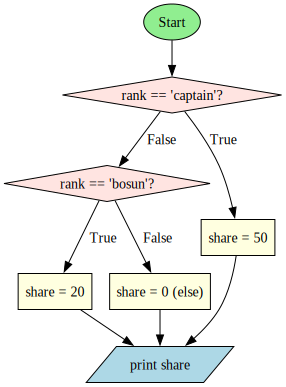

In [3]:
#| echo: false
#@title 📊 Decision-flowchart code (click to show)
from graphviz import Digraph

fc = Digraph(graph_attr={"rankdir": "TB"})
fc.node("S", "Start", shape="ellipse", style="filled", fillcolor="lightgreen")
fc.node("C", "rank == 'captain'?", shape="diamond", style="filled", fillcolor="mistyrose")
fc.node("B", "rank == 'bosun'?",   shape="diamond", style="filled", fillcolor="mistyrose")
fc.node("P1", "share = 50", shape="box", style="filled", fillcolor="lightyellow")
fc.node("P2", "share = 20", shape="box", style="filled", fillcolor="lightyellow")
fc.node("P3", "share = 0 (else)", shape="box", style="filled", fillcolor="lightyellow")
fc.node("E", "print share", shape="parallelogram", style="filled", fillcolor="lightblue")
fc.edge("S", "C")
fc.edge("C", "P1", label=" True")
fc.edge("C", "B", label=" False")
fc.edge("B", "P2", label=" True")
fc.edge("B", "P3", label=" False")
fc.edge("P1", "E"); fc.edge("P2", "E"); fc.edge("P3", "E")
fc

**Reading it:** each diamond is one condition; the `True` arrow runs that branch, the `False` arrow falls through to the next test. Exactly one yellow box is ever reached. That single-path-through is the visual definition of `if`/`elif`/`else`.

### Decisions Inside Decisions

A decision can live *inside* another. The Sentry, **Doran Holt** — who won't let his own mother in without the password — needs two things true, in order: first a valid password, then a place on the list. The next cell nests one `if` inside another.

In [4]:
# ⬇️ CHANGE THESE, THEN RE-RUN
has_password = True
on_the_list  = False
# ----------------------------------

if has_password:
    if on_the_list:
        print("Welcome aboard.")
    else:
        print("Password ok — but you're not on the list.")
else:
    print("No password, no entry.")

Password ok — but you're not on the list.


### Understanding the Code

- The **indentation level** shows the nesting: the inner `if`/`else` is two levels deep, so it only runs when the outer `if` is `True`.
- This same logic could be written with `and` from Notebook 3: `if has_password and on_the_list:`. Nesting is clearer when the two checks need *different* messages; `and` is shorter when they don't. Both are valid — choose the readable one.

## Combining Conditions: `and`, `or`, `not`

One test often isn't enough. Hook won't pay out unless a crew member is **both** signed to the Articles **and** present at muster. Python joins tests with three words:

- `and` — `True` only when **both** sides are true
- `or` — `True` when **at least one** side is true
- `not` — flips a value: `not True` is `False`

The next cell decides whether a crew member gets paid.

In [5]:
# ⬇️ CHANGE THESE, THEN RE-RUN
signed   = True
present  = True
deserted = False
# ----------------------------------

if signed and present and not deserted:
    print("Pay this crew member.")
elif signed or present:
    print("Hold for review.")
else:
    print("No claim.")

Pay this crew member.


### ✏️ Your Turn — Clear for Takeoff

The ship may launch only if it has fuel **and** the crew is aboard **and** it is **not** storming. Set the three boxes below, then print a single `True`/`False` for whether it can launch.

In [ ]:
#| eval: false
# ⬇️ CHANGE THESE, THEN RE-RUN
has_fuel    = True
crew_aboard = True
storming    = False
# ----------------------------------

# TODO: print one True/False value: can the ship launch?

### Understanding the Code

- `signed and present and not deserted` is `True` only when **all three** parts hold: `signed` is `True`, `present` is `True`, and `deserted` is `False` (so `not deserted` is `True`).
- Python reads `not` first, then `and`, then `or` — like `×` before `+` in maths. When in doubt, add brackets: `(signed and present) or captain` makes the grouping plain.
- **Short-circuit:** with `and`, if the first part is `False`, Python doesn't bother checking the rest — the answer can't change. `or` stops at the first `True`. Put the cheapest or most likely test first.

## Repeating Until Done: `while`

**Peter Pan** is the field agent who never quits. A `while` loop is his whole personality: **repeat a block as long as a condition stays `True`.**

```text
while <condition>:
    <repeat this block>
```

The condition is re-checked **before every pass**. Use `while` when you don't know in advance how many repetitions you'll need — only the condition that means "stop." The next cell counts a clock down to zero.

In [6]:
# ⬇️ CHANGE THIS, THEN RE-RUN
minutes = 5
# ----------------------------------

while minutes > 0:
    print(f"The crocodile clock ticks: {minutes} left")
    minutes = minutes - 1        # progress toward the exit

print("Time's up. Tick tock.")

The crocodile clock ticks: 5 left
The crocodile clock ticks: 4 left
The crocodile clock ticks: 3 left
The crocodile clock ticks: 2 left
The crocodile clock ticks: 1 left
Time's up. Tick tock.


### Understanding the Code — the Three-Part Loop

Every safe `while` loop has three parts. Lose one and it breaks:

1. **Initialise** — `minutes = 5` before the loop.
2. **Test** — `while minutes > 0:` re-checked each pass.
3. **Progress** — `minutes = minutes - 1` *moves the variable toward the stop condition*.

The line that matters most is the progress line. Delete it and `minutes` is always 5, the condition is always `True`, and the loop runs **forever**.

### ⚠️ The Infinite Loop

Peter Pan refuses to grow up. As code, he is a loop with no progress toward its exit:

```python
age = 10
while age < 18:
    print("Peter refuses to grow up.")
    # age never changes -> the condition is always True -> forever
```

*(Deliberately not a runnable cell.)* If you ever start one by accident, **stop it** in Colab with the ⏹ button or **Runtime → Interrupt execution**. The cure is always the same: make sure something inside the loop moves the test toward `False`.

### Will It Always Stop?

Peter's loop never ends because nothing moves it toward the exit. That points at a quiet promise *every* loop makes: **something inside it must change so the condition will eventually become `False`.** Break that promise and the loop runs forever.

Now a question that sounds easy and isn't: could you write one program that reads *any* loop and decides whether it will ever stop? For a small loop, sure — you trace it by hand. But in general, **no program can answer that question for every possible loop.** That isn't a gap in our cleverness; it was *proven* impossible. The result is called the **halting problem**, and we meet it properly in Notebook 7. For now, notice where you are: you bumped into one of the deepest limits in all of computer science just by writing a `while` loop.

### 💭 Think About It — Will It Always Stop?

You saw that a loop with the wrong condition can run forever. Sometimes it's obvious a loop will end; sometimes it really isn't.

- For an everyday process (boiling pasta, waiting for a bus, searching your room for your keys), how do you *know* it will eventually finish? Is that guarantee built into the steps, or do you just trust it?
- Can you describe a set of instructions that might run forever for some starting inputs but stop for others?
- Why might it matter — for software running a plane or a hospital monitor — to be *certain* a program will always finish what it started?

There are no single right answers here — share a sentence or two on each.

### The `while` Loop, as a Flowchart

A `while` loop is the first flowchart with an arrow that goes *backwards*. Watch the **"loop back"** edge: the diamond is tested, the body runs, and control returns to the diamond — over and over, until the test is finally `False`.

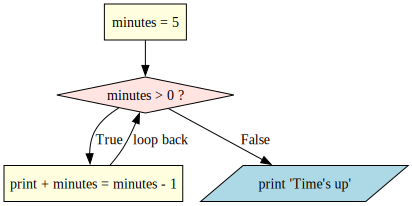

In [7]:
#| echo: false
#@title 📊 While-loop flowchart code (click to show)
wf = Digraph(graph_attr={"rankdir": "TB"})
wf.node("S", "minutes = 5", shape="box", style="filled", fillcolor="lightyellow")
wf.node("C", "minutes > 0 ?", shape="diamond", style="filled", fillcolor="mistyrose")
wf.node("B", "print + minutes = minutes - 1", shape="box", style="filled", fillcolor="lightyellow")
wf.node("E", "print 'Time's up'", shape="parallelogram", style="filled", fillcolor="lightblue")
wf.edge("S", "C")
wf.edge("C", "B", label=" True")
wf.edge("B", "C", label=" loop back")
wf.edge("C", "E", label=" False")
wf

**Reading it:** the `loop back` arrow *is* the repetition. The only way out is the `False` edge — which only happens because the body changes `minutes`. No backward arrow that can ever turn `False` = infinite loop.

### ✏️ Your Turn — Count the Pixie Dust

The ship burns one measure of pixie dust each minute. Start with some `dust` and use a `while` loop to print how much is left each minute until it runs out, then print *Out of dust!*. Make sure something changes each pass — otherwise you'll loop forever.

In [ ]:
#| eval: false
# ⬇️ CHANGE THIS, THEN RE-RUN
dust = 5
# ----------------------------------

# TODO: while dust > 0, print how much is left, then reduce dust by 1.
#       After the loop, print "Out of dust!".

## Repeating a Known Number of Times: `for`

**Nana**, head of safety, patrols the whole nursery every night, in order, and counts every child twice because once is not rigorous. When you know *exactly what to step through*, use a `for` loop.

`range(1, n + 1)` produces `1, 2, ..., n` (the `+ 1` because `range` stops *before* its second number — the rule from Notebook 1's loops). The next cell patrols a fixed number of children.

In [8]:
# ⬇️ CHANGE THIS, THEN RE-RUN
children = 4
# ----------------------------------

for child in range(1, children + 1):
    print(f"Nana checks child #{child}")

print("Nursery secure.")

Nana checks child #1
Nana checks child #2
Nana checks child #3
Nana checks child #4
Nursery secure.


### Understanding the Code

- `child` is the **loop variable**. Each pass it automatically takes the next value from `range` — you never update it yourself (the difference from `while`).
- The loop runs a **known** number of times: exactly `children`. No infinite-loop risk — `range` is finite.
- Use `for` when you can say *"do this once for each ___"*; use `while` when you can only say *"keep going until ___"*.

### Looping Directly Over a List

A `for` loop doesn't need `range` at all — it can step straight through a **list**, handing you each item in turn. This is the cleanest loop in Python, and the next cell walks a roster of names.

In [9]:
# ⬇️ CHANGE THIS LIST, THEN RE-RUN
roster = ["Wendy", "John", "Michael"]
# ----------------------------------

for name in roster:
    print(f"Accounted for: {name}")

print(f"{len(roster)} children on the roster.")

Accounted for: Wendy
Accounted for: John
Accounted for: Michael
3 children on the roster.


### Understanding the Code

- `for name in roster:` walks the list element by element; `name` is each child in turn. No `range`, no indexing.
- `len(roster)` is the list's length (the same `len` from Notebook 3). Lists get a full notebook of their own next — here they're just something to loop over.

### Totalling With an Accumulator

Looping is most useful when each pass *adds to a running total*. You've seen this exact pattern before — Notebook 1's Lovelace factorial used `running_product`. The next cell uses the same idea to total supplies across a roster.

In [10]:
# ⬇️ CHANGE THESE, THEN RE-RUN
supplies_per_child = 3
roster = ["Wendy", "John", "Michael", "Tootles"]
# ----------------------------------

total = 0                         # the accumulator — start empty
for name in roster:
    total = total + supplies_per_child

print(f"Pack {total} supply units for {len(roster)} children.")

Pack 12 supply units for 4 children.


### ✏️ Your Turn — Total the Supplies

Each child needs a different number of supplies. Use a `for` loop and an **accumulator** to add up the list below and print the total. (Try an empty list too — what should it print?)

In [ ]:
#| eval: false
# ⬇️ CHANGE THIS LIST, THEN RE-RUN
needs = [3, 1, 5, 1, 3]
# ----------------------------------

# TODO: start total = 0, add each value in needs with a for loop,
#       then print the total.

### Understanding the Code

This is the **accumulator pattern**, now inside a real loop:

- **Initialise before the loop:** `total = 0`.
- **Update inside the loop:** `total = total + supplies_per_child`, once per child.
- **Use after the loop:** print it.

Initialise / update / use. Almost every "add up / count / collect" task is this pattern — the same shape as Lovelace's `running_product`.

## Steering Loops: `break` and `continue`

Two keywords change a loop's flow, and both are almost always guarded by an `if`:

- **`break`** — leave the loop *immediately*, skip whatever's left.
- **`continue`** — skip the *rest of this pass* and jump to the next one.

The next cell searches a roster: it skips one name and stops entirely at another.

In [11]:
# ⬇️ CHANGE THESE, THEN RE-RUN
roster = ["Wendy", "John", "Slightly", "Michael", "Nibs"]
looking_for = "Slightly"
# ----------------------------------

for name in roster:
    if name == "John":
        continue                    # skip John, keep searching
    if name == looking_for:
        print(f"Found {name}! Stop the search.")
        break                       # leave the loop entirely
    print(f"Checked {name}")

print("Search ended.")

Checked Wendy
Found Slightly! Stop the search.
Search ended.


### ✏️ Your Turn — Find the Stowaway

Loop through `roster`, printing each name you check. The moment you reach `"stowaway"`, print *Caught!* and `break` out of the loop.

In [ ]:
#| eval: false
# ⬇️ CHANGE THESE, THEN RE-RUN
roster = ["Wendy", "John", "stowaway", "Michael"]
# ----------------------------------

# TODO: loop the roster; print each name; when you hit "stowaway",
#       print "Caught!" and break.

### Understanding the Code

- `continue` at `John`: the `print(f"Checked ...")` line is skipped *for John only*; the loop moves straight to `Slightly`.
- `break` at `Slightly`: the loop stops dead. `Michael` and `Nibs` are never checked.
- This is **nested logic**: an `if` inside a `for`. Most real loops look like this — repetition wrapped around decisions.

### Loops Inside Loops

A loop can contain another loop. Nana's rounds aren't one night — they're *every child, every night*. The next cell puts a child-loop inside a night-loop.

In [12]:
# ⬇️ CHANGE THESE, THEN RE-RUN
nights = 2
children = 3
# ----------------------------------

for night in range(1, nights + 1):
    for child in range(1, children + 1):
        print(f"Night {night}: Nana checks child #{child}")

Night 1: Nana checks child #1
Night 1: Nana checks child #2
Night 1: Nana checks child #3
Night 2: Nana checks child #1
Night 2: Nana checks child #2
Night 2: Nana checks child #3


### Understanding the Code

- The **inner loop runs fully for each single pass of the outer loop**. Outer at `night 1` → inner counts all 3 children → *then* outer moves to `night 2`.
- Total lines printed = `nights × children` = 2 × 3 = 6. Nested loops multiply; that matters a lot for speed later in the course.
- Indentation depth shows the nesting — read it like an outline.

## The Three Building Blocks: Why This Is All You Need

Stop and notice something big. You have now seen every kind of control flow there is — not "the ones we had time for," but *every* kind. Any algorithm, however huge, is built from just **three** structures:

1. **Sequence** — do one step, then the next, in order. (Notebook 3's straight-line code.)
2. **Selection** — choose between paths. (`if` / `elif` / `else`.)
3. **Iteration** — repeat a block. (`while` and `for`.)

That is the whole toolkit. A flight controller, a search engine, a video game — all of it is sequence, selection, and iteration, nested and combined. There is no secret fourth kind of control flow waiting in a later chapter.

This isn't just a tidy observation — it's a proven theorem. In 1966, **Corrado Böhm** and **Giuseppe Jacopini** showed that those three structures are *enough* to express any computation at all. It's called the **structured program theorem**, and it settled a real fight.

Early programmers leaned on a command called `goto`, which could jump to *anywhere* else in the code. Programs became "spaghetti" — tangled jumps no human could follow. Böhm and Jacopini proved `goto` was never necessary: sequence, selection, and iteration can do everything it could, in an orderly way. Modern languages quietly retired `goto`, and Wendy's rescue plans stay readable because of it. The diagram below shows the three shapes — the entire grammar of control flow.

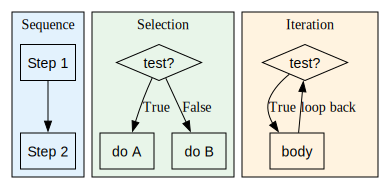

In [13]:
#| echo: false
#@title 🧱 The three building blocks — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="TB")
g.attr("node", fontname="Helvetica")

with g.subgraph(name="cluster_seq") as s:
    s.attr(label="Sequence", style="filled", fillcolor="#e3f2fd")
    s.node("s1", "Step 1", shape="box")
    s.node("s2", "Step 2", shape="box")
    s.edge("s1", "s2")

with g.subgraph(name="cluster_sel") as s:
    s.attr(label="Selection", style="filled", fillcolor="#e8f5e9")
    s.node("d", "test?", shape="diamond")
    s.node("y", "do A", shape="box")
    s.node("n", "do B", shape="box")
    s.edge("d", "y", label="True")
    s.edge("d", "n", label="False")

with g.subgraph(name="cluster_it") as s:
    s.attr(label="Iteration", style="filled", fillcolor="#fff3e0")
    s.node("t", "test?", shape="diamond")
    s.node("b", "body", shape="box")
    s.edge("t", "b", label="True")
    s.edge("b", "t", label="loop back")
g

### 💭 Think About It — Is That Really All There Is?

You just learned that sequence, selection (`if`), and repetition (loops) are enough to express *any* algorithm at all.

- Does it surprise you that everything a computer does reduces to just these three? Can you think of something a computer does that feels like it must need more — and guess how it might actually be built from the three?
- Human instructions from a coach, teacher, or parent rarely sound like pure sequence/selection/repetition. What do humans add that these three building blocks leave out?
- If these three are all you truly need, why do programming languages bother having so many other features? What might they be for?

There are no single right answers here — share a sentence or two on each.

**Reading it:** Three shapes, left to right — a straight line (sequence), a fork (selection), and a loop-back arrow (iteration). Every program you ever write or read is some arrangement of just these three. That's a genuinely surprising fact, and it's the theoretical heart of this notebook.

## Decomposing Problems into Functions

**Wendy Darling** never tackles The Big Contract as one job. She splits it into named sub-tasks, solves each once, and reuses them. That is **decomposition**, and the tool is the **function**.

You met `def` informally in Notebook 1. Here it is, precisely:

```text
def name(parameters):
    <body>
    return <a value>
```

- **Parameters** are named inputs the caller fills in.
- **`return`** hands exactly one value back.
- **Calling** it — `name(arguments)` — *is itself an expression* that becomes the returned value. The next cell defines and calls one.

In [15]:
def supply_units(children, per_child):
    return children * per_child

# ⬇️ CHANGE THESE CALLS, THEN RE-RUN
needed = supply_units(4, 3)
print(f"Pack {needed} units.")
print(supply_units(10, 2))

Pack 12 units.
20


### Understanding the Code

- `def supply_units(children, per_child):` defines the function but **does not run it**. Nothing happens until it's *called*.
- `supply_units(4, 3)` calls it: `children` becomes `4`, `per_child` becomes `3`, the body runs, `return` hands back `12`.
- `needed = supply_units(4, 3)` stores that returned value; `print(supply_units(10, 2))` uses it directly. The call behaves exactly like the value it returns.

### A Function Is a Black Box

Here's the deeper idea hiding inside `def`. Once Wendy has `supply_units`, she can *use* it without remembering how it works inside. The function's name and its inputs and output are its **interface** — the promise. The code in the body is the **implementation**. The caller is free to ignore the implementation entirely.

That separation is **abstraction**, and it is arguably the single most important idea in computer science: hide the details behind a simple surface so you can think about one thing at a time. You already trust it constantly — `print()` and `int()` are black boxes you use every day without ever reading their source code. Every function you write becomes one more black box that future-you, or a teammate, can build on without reopening it.

This is also *why* we decompose. A big problem split into well-named functions is a stack of black boxes, each small enough to understand and test on its own. Solving a problem by breaking it down until each piece is easy, then building back up, is called **top-down design** — the core problem-solving move in computer science.

Decomposition has a second payoff: it kills repetition. Write a rule once, in one function, and call it everywhere instead of copying the logic. Programmers have a name for this principle — **DRY: Don't Repeat Yourself.** Repeated code is repeated bugs; a single function is a single place to fix.

### `return` vs `print`

This is the single most common point of confusion with functions, so it gets its own example. `return` and `print` look similar but do completely different things. The next cell defines one function that **returns** and one that only **prints**, then inspects what the caller actually gets back.

In [16]:
def adds(a, b):
    return a + b          # hands the value back

def shows(a, b):
    print(a + b)          # only displays it; returns nothing

r = adds(2, 3)            # r holds 5
s = shows(2, 3)           # prints 5, but s holds None
print("r =", r, "  s =", s)

5
r = 5   s = None


### ✏️ Your Turn — Write a Function

Write a function `supplies_for(children, per_child)` that **returns** the total supplies needed (children × per_child). Then call it and print the result. Return the value — don't `print` inside the function.

In [ ]:
#| eval: false
# TODO: define supplies_for(children, per_child) that RETURNS children * per_child,
#       then call it and print the result.

# def supplies_for(children, per_child):
#     ...

### Understanding the Code

- `return` gives a value **back to the program** — you can store it, do maths with it, pass it on.
- `print` only puts text **on the screen** — the program gets nothing back.
- A function with no `return` automatically returns `None`. That's why `s` is `None`: `shows` printed `5` but handed nothing back. If a function's result "disappears," you almost certainly printed where you meant to return.

### Scope: A Box That Stays Inside

Remember the "named box" from Notebook 3? Inside a function, a variable lives in a box that **only exists while that function runs**. The next cell makes a local variable, returns it, and then tries to peek at it from outside.

In [17]:
def brew():
    secret = "pixie dust"      # a LOCAL box — exists only inside brew()
    return secret

print(brew())                  # works: 'pixie dust'

# Uncomment the next line to see the error scope protects you from:
# print(secret)                # NameError: 'secret' is not defined out here

pixie dust


### Understanding the Code

- `secret` is **local** to `brew()`. When the function returns, the box is thrown away.
- Using `secret` outside is a `NameError` — out there, the name was never defined.
- Parameters are local too. This is *why* functions are safe building blocks: their internals can't collide with names elsewhere. Decomposition works because each piece is sealed.

### Picture It: Arguments In, Value Out

A function call is a small round trip. The diagram below shows it: the caller passes **arguments in**, the function works in its own **sealed local scope**, and a single **value comes back out**.

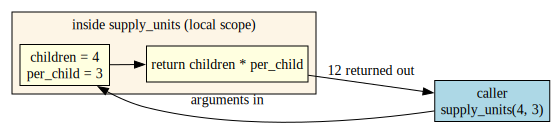

In [18]:
#| echo: false
#@title 📊 Function-call diagram code (click to show)
g = Digraph(graph_attr={"rankdir": "LR"})
g.node("C", "caller\nsupply_units(4, 3)", shape="box", style="filled", fillcolor="lightblue")
with g.subgraph(name="cluster_fn") as f:
    f.attr(label="inside supply_units (local scope)", style="filled", fillcolor="oldlace")
    f.node("P", "children = 4\nper_child = 3", shape="box", style="filled", fillcolor="lightyellow")
    f.node("R", "return children * per_child", shape="box", style="filled", fillcolor="lightyellow")
    f.edge("P", "R")
g.edge("C", "P", label=" arguments in ")
g.edge("R", "C", label=" 12 returned out ")
g

**Reading it:** the shaded box is the local scope — `children` and `per_child` exist *only* in there. The caller never sees inside; it only sends arguments in and receives one value out. That sealed boundary is exactly what makes functions reusable.

### Default Values and Keyword Arguments

A parameter can carry a **default value**, used only when the caller leaves it out. And when a function takes several parameters, you can **name** them at the call so you don't have to remember the order. The next cell gives `per_child` a default and shows both ways to call.

In [19]:
def supply_units(children, per_child=3):
    return children * per_child

print(supply_units(4))                          # per_child defaults to 3 → 12
print(supply_units(4, 5))                        # override by position    → 20
print(supply_units(children=10, per_child=2))    # named arguments         → 20
print(supply_units(per_child=2, children=10))    # named → order doesn't matter → 20

12
20
20
20


### Understanding the Code

- `per_child=3` is a **default**. `supply_units(4)` leaves it out, so `per_child` is `3`. Defaults let one function handle both the common case and the special case.
- Arguments **by position** (`supply_units(4, 5)`) match left to right. Arguments **by keyword** (`children=10, per_child=2`) name each one, so order stops mattering and the call reads like a sentence.
- Rule of thumb: parameters **with** a default come **after** those without. `def f(a, b=1)` is fine; `def f(a=1, b)` is an error.

### Docstrings: Saying What a Function Does

A function that works but nobody understands is a liability. A **docstring** is a short string written as the first line *inside* the function. It's the standard place to say, in one sentence, what the function does — and Python reads it back through `help()`. The next cell adds one.

In [20]:
def supply_units(children, per_child=3):
    """Return the total supply units needed for a group of children."""
    return children * per_child

help(supply_units)              # Python prints the docstring
print(supply_units.__doc__)     # ...or read it directly

Help on function supply_units in module __main__:

supply_units(children, per_child=3)
    Return the total supply units needed for a group of children.

Return the total supply units needed for a group of children.


### ✏️ Your Turn — Document It

Take your `supplies_for` function from above. Give `per_child` a **default** of `3`, add a one-line **docstring** saying what it does, then call it once using a **keyword argument**.

In [ ]:
#| eval: false
# TODO: add a default (per_child=3) and a docstring, then call with a keyword arg.

# def supplies_for(children, per_child=3):
#     """..."""
#     ...

### Understanding the Code

- The triple-quoted line right under `def` is the docstring. It doesn't change what the function *does* — it documents it.
- `help(supply_units)` and `supply_units.__doc__` both read it back, and Colab shows it as a tooltip when you call the function.
- A good docstring says **what** the function returns and **what** the inputs mean — not how every line works. One clear sentence beats a paragraph.

## The Workflow, With Functions: the Lost Crew Supply Run

Now decomposition pays off on a real problem, through the full workflow. Wendy's problem, stated plainly:

> *Given a roster where each child has a status (`"medical"`, `"escort"`, or anything else meaning `"ready"`), compute the total supply units the rescue needs. Medical children need 5, escort children need 3, ready children need 1.*

- **Inputs:** `roster` (a list of status strings)
- **Output:** total supply units (an integer)
- **Decomposition:** one function decides *one child* (`assess`); another loops the whole roster and accumulates (`mission_total`).

### Step 2 — Pseudocode

```text
FUNCTION assess(status):
  1. IF status = "medical":  RETURN 5
  2. IF status = "escort":   RETURN 3
  3. OTHERWISE:              RETURN 1

FUNCTION mission_total(roster):
  1. SET total = 0
  2. FOR each status in roster:
       2a. SET total = total + assess(status)
  3. RETURN total
```

Two small algorithms. `mission_total` *calls* `assess` — a function using a function. That's decomposition in one picture.

### Step 3 — The Flowchart

Here is `mission_total` as a flowchart. Notice it's a `for` loop over the roster with the **accumulator** inside — and each pass calls `assess` to decide that one child.

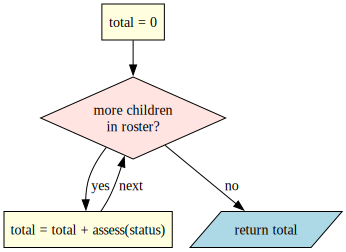

In [21]:
#| echo: false
#@title 📊 Workflow flowchart code (click to show)
mf = Digraph(graph_attr={"rankdir": "TB"})
mf.node("S", "total = 0", shape="box", style="filled", fillcolor="lightyellow")
mf.node("C", "more children\nin roster?", shape="diamond", style="filled", fillcolor="mistyrose")
mf.node("A", "total = total + assess(status)", shape="box", style="filled", fillcolor="lightyellow")
mf.node("R", "return total", shape="parallelogram", style="filled", fillcolor="lightblue")
mf.edge("S", "C")
mf.edge("C", "A", label=" yes")
mf.edge("A", "C", label=" next")
mf.edge("C", "R", label=" no")
mf

**Reading it:** the diamond is the `for` loop's "any more items?" test; the `yes` arrow loops back through the accumulator; the `no` arrow leaves with the finished `total`. The `assess(status)` call hides a whole second flowchart inside one box — that's the power of decomposition.

### Step 4 — The Python

Now translate both pseudocode functions line for line. Editable roster at the top so you can test it; the verification comes right after.

In [22]:
# ⬇️ CHANGE THIS ROSTER, THEN RE-RUN
roster = ["medical", "ready", "escort", "ready", "medical"]
# ----------------------------------

def assess(status):
    if status == "medical":
        return 5
    elif status == "escort":
        return 3
    else:
        return 1

def mission_total(children):
    total = 0
    for status in children:
        total = total + assess(status)
    return total

print(f"Supplies needed: {mission_total(roster)} units")

Supplies needed: 15 units


### Understanding the Code

- `assess` is pure decision logic — one `if`/`elif`/`else`, one `return` per branch. It handles **one** child and nothing else.
- `mission_total` is the accumulator pattern (initialise / update / use) **looping the roster** and *calling* `assess` each pass.
- The last line is the whole program: call one function, print the result. Each piece is small enough to check on its own — the entire point of decomposition.

### Step 5 — Verify by Hand

`roster = ["medical", "ready", "escort", "ready", "medical"]`

| status | assess |
|---|---|
| medical | 5 |
| ready | 1 |
| escort | 3 |
| ready | 1 |
| medical | 5 |

Total = 5 + 1 + 3 + 1 + 5 = **15**. Run the cell — it should print `15`. Predicting the answer *before* running is the habit; the next section makes it a discipline.

## Testing With Edge Cases

**Mr. Smee** reads the fine print nobody else will. His idea of a threat is *"but what if there are zero children?"* — and he is always right to ask.

Code that works on the *normal* input often shatters on the *extreme* one. Before trusting any function, run Smee's checklist:

- **Zero / empty** — an empty list, the number 0
- **Negative** — can a count go below zero?
- **The boundary** — exactly the value where behaviour changes
- **The unexpected** — a status nobody planned for
- **Off-by-one** — first and last items of a loop

The next cell looks correct — until Smee asks his question.

In [23]:
def average_supplies(roster):
    return mission_total(roster) / len(roster)

print(average_supplies(["medical", "ready"]))   # fine: 6 / 2 = 3.0

# Smee asks: what about an empty roster?
# Uncomment to see it shatter:
# print(average_supplies([]))                    # ZeroDivisionError

3.0


### Understanding the Code

- On a normal roster, `average_supplies` is correct. On an **empty** roster, `len(roster)` is `0`, and dividing by zero crashes — the *exact* input Smee warned about.
- Nothing in the function is "wrong" on the happy path. The bug only exists at the edge. **That's why you test edges deliberately** — the normal case hides them.
- The habit: before running, write down what *should* happen for the weird inputs. Then run and compare. Surprises are bugs.

### ✏️ Your Turn — Break It (Smee's Checklist)

The scaffold below re-creates `assess`, `mission_total`, and `average_supplies`. Your job is to **break them on purpose**.

1. Find **two** inputs that break or mislead them — at least an **empty** roster and an **unexpected status** (does `"VIP"` silently count as `ready`? Is that intended?).
2. For each, jot down the input, what you *expected*, and what *actually* happened.
3. **Fix one** — for example, make `average_supplies` return `0` for an empty roster instead of crashing.

Finding the breaking input *is* the skill. Smee is delighted when something breaks — that's a bug caught before the contract failed.

In [24]:
# ✏️ Exercise 3 workspace.

def assess(status):
    if status == "medical":
        return 5
    elif status == "escort":
        return 3
    else:
        return 1

def mission_total(children):
    total = 0
    for status in children:
        total = total + assess(status)
    return total

def average_supplies(roster):
    return mission_total(roster) / len(roster)

# ⬇️ TRY BREAKING INPUTS HERE
print(mission_total(["medical", "ready"]))
# print(average_supplies([]))        # <- start here


6


## Practice: PyQuiz

More practice — same drill as Notebook 3. PyQuiz hands you a problem,
you fill in the function body, click **Run Tests**. The bank below is
heavier on `if`/`elif`/`else` and loops, since that's what this
notebook taught you.

A reminder on the two accumulator patterns you'll use a lot:

```python
# sum: start at 0, then +=
total = 0
for i in range(1, n + 1):
    total += i

# product: start at 1, then *=
product = 1
for i in range(1, n + 1):
    product *= i
```

Run the cell below to load the practice tool.


In [ ]:
# PyQuiz bootstrap — works in Colab or any local Jupyter.
import os, urllib.request
REPO = "https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main"
if not os.path.exists("pyquiz.py"):
    urllib.request.urlretrieve(f"{REPO}/tools/python_code_quiz/pyquiz.py", "pyquiz.py")

from pyquiz import PracticeTool
practice_tool = PracticeTool(
    json_url=f"{REPO}/tools/python_code_quiz/banks/nb04_control_flow.json"
)


## ✏️ Capstone — Build a Turn-Based Survival Game (AI-Assisted)

This is where the whole notebook comes together. You'll build a small **turn-based game**: the player takes one action per turn, the game **loops** through the turns, each turn **decides** what happens, and the rules live in **functions** you write. Decisions, loops, functions — the three things this notebook is about, in one program.

The default theme is the Lost Crew flying home — but **pick your own**: a dungeon crawl, a spaceship limping to port, a zombie night, a bakery rush before closing. Whatever it is, your game must:

- **repeat** over several turns (a loop),
- **branch** on what the player chooses or what randomly happens (`if` / `elif` / `else`),
- be **broken into at least one function** you wrote (for example, one that resolves a single turn), and
- track a **resource** that rises and falls — pixie dust, health, fuel, money — with a win or lose ending.

**Step 1 — Design it first (before the AI).** In a markdown cell, jot down: your theme, the resource you track and its starting amount, the 2–3 actions a player can take each turn, what makes each one good or risky, and how the game is won or lost.

**Step 2 — Turn your design into a prompt.** Fill the blanks and send it to Gemini (or Claude / ChatGPT):

> *Write a small turn-based text game as a Python program for Google Colab. Theme: **[your theme]**. The player starts with **[N] [resource]** and plays up to **[number]** turns. Each turn they choose one of: **[your actions]**. Use `if`/`elif`/`else` to resolve the choice and change the resource. Put the per-turn logic in its own function. The game ends when **[win condition]** or **[lose condition]**. Show the resource each turn. Keep it short and beginner-readable.*

**Step 3 — Get the bones working, then test.** Paste it into the cell below and **run it now**. Get the simplest version working first — one action, the resource changes, the loop ends — and check it by hand before adding more.

**Step 4 — Add the bells and whistles.** Once the core runs, add **one or two** extras, testing after each: a random event each turn, a second resource, a high score, or a risky action with a big payoff.

**Step 5 — Test it like Smee.** Try to break it: a turn count of 0, an action that isn't on the menu, a resource that goes negative. Fix one thing it gets wrong.

**Step 6 — Reflect.** In a markdown cell, write 2–3 sentences: what did the AI get wrong or what did you improve, and how did you fix it?

Remember the course rule: *AI is a fast first draft. You verify.*

In [ ]:
#| eval: false
# ✏️ Paste your AI-built turn-based game here, then run it and fix what's broken.

## Key Terms

- **Conditional** — Code that runs only when a condition is `True`.
- **`if` / `elif` / `else`** — Choose exactly one branch; checked top-down, first `True` wins.
- **Nested decision** — An `if` inside another `if`.
- **`and` / `or` / `not`** — Combine or flip conditions; evaluated `not`, then `and`, then `or`.
- **Short-circuit** — `and` / `or` stop checking once the result is already settled.
- **`while` loop** — Repeats a block while a condition stays `True`.
- **`for` loop** — Repeats once for each item in a range or list.
- **Loop variable** — The variable a `for` loop assigns each pass.
- **`range(a, b)`** — The integers from `a` up to but not including `b`.
- **Iteration** — Repeating a block of code; one of the three control structures. (Also: one pass through a loop body.)
- **Infinite loop** — A loop whose condition never becomes `False`; nothing makes progress toward the exit.
- **`break` / `continue`** — Leave the loop entirely / skip to the next iteration.
- **Accumulator** — A variable that builds a result across loop passes (initialise / update / use).
- **Function** — A named, reusable block: `def name(parameters): ... return value`.
- **Parameter / argument** — The named input in the definition / the actual value passed in a call.
- **Default value** — A fallback for a parameter, used when the caller omits that argument.
- **Keyword argument** — An argument passed by name (`per_child=2`), so the call order stops mattering.

- **Docstring** — A one-line string just inside a function that says what it does; read back by `help()`.
- **`return`** — Hands one value back to the caller; absent `return` yields `None`.
- **`None`** — Python's "no value" value.
- **Scope** — Where a name is visible; variables made inside a function are **local** to it.
- **Decomposition** — Breaking a problem into small, separately-testable functions.
- **Edge case** — An extreme or unusual input (empty, zero, negative, boundary) that often exposes bugs.
- **Nested loop** — A loop inside a loop; total passes multiply.
- **Sequence** — The simplest control structure: run steps one after another, in order.
- **Selection** — Choosing between paths (`if` / `elif` / `else`); one of the three control structures.
- **Structured program theorem** — The proven result (Böhm & Jacopini, 1966) that any algorithm can be built from just sequence, selection, and iteration.
- **`goto`** — An old command that could jump anywhere in the code; shown to be unnecessary and now avoided.
- **Halting problem** — The proven impossibility of writing one program that decides whether *any* given program will stop; introduced fully in Notebook 7.
- **Abstraction** — Hiding details behind a simple surface (a name, inputs, an output) so you can use something without knowing how it works inside.
- **Black box** — Something you use through its interface without seeing its implementation; a function is one.
- **Top-down design** — Solving a problem by breaking it into smaller sub-problems until each is easy, then building back up.
- **DRY (Don't Repeat Yourself)** — Write a rule once in a function and reuse it, rather than copying code.

## Summary

- **`if` / `elif` / `else`** make a program choose; the condition is a boolean expression; exactly one branch runs.
- **`and` / `or` / `not`** combine conditions into one test, and short-circuit once the answer is settled.
- **`while`** repeats until a condition turns `False` — and needs initialise / test / **progress**, or it loops forever.
- **`for`** repeats a known number of times — over a `range` or a list; pair it with an **accumulator** to total things up.
- **`break` / `continue`** steer loops; loops + ifs nest, and nested loops multiply.
- **The three building blocks are everything.** Sequence, selection, and iteration are a *complete* set — the **structured program theorem** proves no fourth kind of control flow is needed.
- **Functions are abstraction.** Each is a **black box** with an interface and a hidden implementation; decomposing a problem into black boxes is **top-down design**, and reusing one function instead of copying code is the **DRY** principle.
- **"Does it stop?"** is a deeper question than it looks — the **halting problem** is waiting in Notebook 7.
- **Edge cases** are how you find bugs the normal input hides. Predict, then run, then compare.

Choose, repeat, decompose, test. That's most of programming.

## What's Next

We've been looping over lists and pretending they're simple. They aren't — and they're not the only way to organise data. **Notebook 5** is **Collections & Abstract Data Types**: lists, dictionaries, sets, and tuples, and how choosing the right container makes a problem easy or impossible. Wendy's roster is about to get a serious upgrade.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*  
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*